# VAEMark5

In [1]:
import torch 
import torch.nn as nn # Contains neural network layers.
import torch.optim as optim # Contains Optimisers.
from torch.utils.data import DataLoader 
import torch.nn.functional as F # Contains stateless functions (no internel parameters)
from torchinfo import summary # To get network description
import numpy as np
import wandb # W & B Tracking
import matplotlib.pyplot as plt
import ad_tools.tools as tools # Custom build tools for project
import awkward as ak

# Use GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') 
print(device)

cpu


In [2]:
jz0_train_dataset = tools.DatasetMaker("/home/xzcapask/atlas_ad_hllhc/data/atlas_calorimeter_images/JZ0_no_filter.parquet", up_row_num=1)
jz0_valid_dataset = tools.DatasetMaker("/home/xzcapask/atlas_ad_hllhc/data/atlas_calorimeter_images/JZ0_no_filter.parquet", low_row_num = 200, up_row_num = 201)
jz0_test_dataset = tools.DatasetMaker("/home/xzcapask/atlas_ad_hllhc/data/atlas_calorimeter_images/JZ0_no_filter.parquet", low_row_num = 205, up_row_num = 206)
ggF_test_dataset = tools.DatasetMaker("/home/xzcapask/atlas_ad_hllhc/data/atlas_calorimeter_images/ggF_SM_HH4b.parquet",up_row_num = 1)
vbf_test_dataset = tools.DatasetMaker("/home/xzcapask/atlas_ad_hllhc/data/atlas_calorimeter_images/VBF_SM_HH4b.parquet",up_row_num = 1)
hs_test_dataset = tools.DatasetMaker("/home/xzcapask/atlas_ad_hllhc/data/atlas_calorimeter_images/HZ_bbvv.parquet",up_row_num = 1)

# Datasets to test phi symmetry
# Approximately a rotation of pi/4,pi/2 and 3pi/4 in phi
transform = lambda x: torch.roll(x, shifts = 16, dims = 2)
jz0_test_pi4_dataset = tools.DatasetMaker("/home/xzcapask/atlas_ad_hllhc/data/atlas_calorimeter_images/JZ0_no_filter.parquet", low_row_num = 215, up_row_num = 216, transform = transform)
transform = lambda x: torch.roll(x, shifts = 32, dims = 2)
jz0_test_pi2_dataset = tools.DatasetMaker("/home/xzcapask/atlas_ad_hllhc/data/atlas_calorimeter_images/JZ0_no_filter.parquet", low_row_num = 225, up_row_num = 226, transform = transform)
transform = lambda x: torch.roll(x, shifts = 48, dims = 2)
jz0_test_3pi4_dataset = tools.DatasetMaker("/home/xzcapask/atlas_ad_hllhc/data/atlas_calorimeter_images/JZ0_no_filter.parquet", low_row_num = 235, up_row_num = 236, transform = transform)

In [3]:
jz0_train_loader = DataLoader(jz0_train_dataset, batch_size = 1000) 
jz0_valid_loader = DataLoader(jz0_valid_dataset, batch_size = 1000)
jz0_test_loader = DataLoader(jz0_test_dataset, batch_size = 1) 
ggF_test_loader = DataLoader(ggF_test_dataset, batch_size = 1)
jz0_test_pi4_loader = DataLoader(jz0_test_pi4_dataset, batch_size = 1)
jz0_test_pi2_loader = DataLoader(jz0_test_3pi4_dataset, batch_size = 1)
jz0_test_3pi4_loader = DataLoader(jz0_test_3pi4_dataset, batch_size = 1)
vbf_test_loader = DataLoader(vbf_test_dataset, batch_size = 1)
hs_test_loader = DataLoader(hs_test_dataset, batch_size = 1)

In [4]:
class VAEMark5Encoder(nn.Module):
    """
    Encoder using standard convolutional layers.
    """
    
    def __init__(self, kernel_size = 3, latent_dim = 4):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels = 6, out_channels = 8, kernel_size = kernel_size)
        self.dropout = nn.Dropout(p = 0.2)
        self.conv2 = nn.Conv2d(in_channels = 8, out_channels = 16, kernel_size = kernel_size)
        self.conv3 = nn.Conv2d(in_channels = 16, out_channels = 32, kernel_size = kernel_size)
        self.pool = nn.MaxPool2d(2) 
        self.flatten = nn.Flatten(start_dim = 1) # Flattens images not the batch itself
        self.mu = nn.Linear(768, latent_dim)
        self.logvar = nn.Linear(768, latent_dim)
        self.circular_padding = nn.CircularPad2d((2,2,0,0))



    def forward(self,input):
        input = self.circular_padding(input)
        output1 = F.leaky_relu(self.conv1(input))
        output1 = output1[:,:,:,2:-2]
        output2 = self.pool(output1) 

        input = self.circular_padding(output2)
        output1 = F.leaky_relu(self.conv2(input))
        output1 = output1[:,:,:,2:-2]
        output2 = self.pool(output1) 

        input = self.circular_padding(output2)
        output1 = F.leaky_relu(self.conv3(input))
        output1 = output1[:,:,:,2:-2]
        output2 = self.pool(output1) 
    
        output7 = self.flatten(output2)
        mu_output = self.mu(output7)
        logvar_output = self.logvar(output7)
        return mu_output, logvar_output

class VAEMark5Decoder(nn.Module):
    """
    Decoder using standard convolution layers.
    """

    def __init__(self, kernel_size = 3, latent_dim = 4):
        super().__init__()
        self.deconv1 = nn.ConvTranspose2d(in_channels = 32, out_channels = 16, kernel_size = kernel_size)
        self.deconv2 = nn.ConvTranspose2d(in_channels = 16, out_channels = 8, kernel_size = kernel_size)
        self.deconv3 = nn.ConvTranspose2d(in_channels = 8, out_channels = 6, kernel_size = kernel_size)
        self.upsample1 = nn.Upsample(size = (9,12))
        self.upsample2 = nn.Upsample(size = (22,29))
        self.upsample3 = nn.Upsample(size = (48,62))
        self.linear = nn.Linear(latent_dim,768)
        self.circular_padding = nn.CircularPad2d((2,2,0,0)) # Only adding padding in phi 

    def forward(self, input):
        output1 = self.linear(input)
        output2 = torch.reshape(output1, shape = (-1,32,4,6))

        output3 = self.upsample1(output2)
        output4 = self.circular_padding(output3)
        output5 = F.leaky_relu(self.deconv1(output4))
        output5 = output5[ : , : , : , 2:-2] # Trimming excess
        
        output6 = self.upsample2(output5)
        output7 = self.circular_padding(output6)
        output8 = F.leaky_relu(self.deconv2(output7))
        output8 = output8[:, : , : , 2:-2] # Trimming excess

        output9 = self.upsample3(output8)
        output10 = self.circular_padding(output9)
        output11 = F.leaky_relu(self.deconv3(output10))
        output12 = output11[:,:,:,2:-2]

        return output12

class VAEMark5(nn.Module):
    """
    VAE Mark 1.
    """
    
    def __init__(self, kernel_size = 3, latent_dim = 4):
        super().__init__()
        self.encoder = VAEMark5Encoder(kernel_size = kernel_size, latent_dim = latent_dim)
        self.decoder = VAEMark5Decoder(kernel_size = kernel_size, latent_dim = latent_dim)

    def reparameterise(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std) 
        return mu + eps * std
    
    def forward(self, input):
        mu, logvar = self.encoder(input)
        z = self.reparameterise(mu, logvar)
        output = self.decoder(z)
        return output, mu, logvar

In [5]:
model = VAEMark5(latent_dim = 7)
inputdim = (1,6,50,64)

In [6]:
summary(model, inputdim)

Layer (type:depth-idx)                   Output Shape              Param #
VAEMark5                                 [1, 6, 50, 64]            --
├─VAEMark5Encoder: 1-1                   [1, 7]                    --
│    └─CircularPad2d: 2-1                [1, 6, 50, 68]            --
│    └─Conv2d: 2-2                       [1, 8, 48, 66]            440
│    └─MaxPool2d: 2-3                    [1, 8, 24, 31]            --
│    └─CircularPad2d: 2-4                [1, 8, 24, 35]            --
│    └─Conv2d: 2-5                       [1, 16, 22, 33]           1,168
│    └─MaxPool2d: 2-6                    [1, 16, 11, 14]           --
│    └─CircularPad2d: 2-7                [1, 16, 11, 18]           --
│    └─Conv2d: 2-8                       [1, 32, 9, 16]            4,640
│    └─MaxPool2d: 2-9                    [1, 32, 4, 6]             --
│    └─Flatten: 2-10                     [1, 768]                  --
│    └─Linear: 2-11                      [1, 7]                    5,383
│    

In [16]:
wandb.login()
project = "TESTING VAEMARK5"
config = {"epochs": 10,"lr":1e-3}


model = VAEMark5(latent_dim = 7).to(device)
optimiser = torch.optim.Adam(model.parameters(), lr = config["lr"]) 

valid_recon_losses = []
valid_kl_losses = []
valid_total_losses = []

train_recon_losses = []
train_kl_losses = []
train_total_losses = []



with wandb.init(project = project, config = config) as run:
    for i in range(config["epochs"]):
        train_avg_recon_loss,train_avg_kl_loss, train_avg_total_loss = tools.train(model = model, dataloader = jz0_train_loader, device = device, optimiser = optimiser,loss_function = tools.unadulterated_training_loss, num_events = 1000)
        train_recon_losses.append(train_avg_recon_loss)
        train_kl_losses.append(train_avg_kl_loss)
        train_total_losses.append(train_avg_total_loss)

        valid_avg_recon_loss,valid_avg_kl_loss, valid_avg_total_loss = tools.valid(model = model, dataloader = jz0_valid_loader, device = device, loss_function = tools.testing_loss, num_events = 1000)
        valid_recon_losses.append(valid_avg_recon_loss)
        valid_kl_losses.append(valid_avg_kl_loss)
        valid_total_losses.append(valid_avg_total_loss)

        run.log({"Training Total Loss": train_avg_total_loss,"Training Reconstruction Loss": train_avg_recon_loss, "Training KL Loss": train_avg_kl_loss, "Validation total loss": valid_avg_total_loss,"Validation Reconstruction Loss": valid_avg_recon_loss, "Validation KL Loss": valid_avg_kl_loss})

        torch.save(model.state_dict(), f'/home/xzcapask/atlas_ad_hllhc/data/model_data/VAEMark5/weights/VAEMark5_weights_epoch{i + 1}.pth')
        
        # Saving training and validation losses
        np.save(file = f"/home/xzcapask/atlas_ad_hllhc/data/model_data/VAEMark5/training_validation_losses/validation_total_losses.npy", arr = valid_total_losses)
        np.save(file = f"/home/xzcapask/atlas_ad_hllhc/data/model_data/VAEMark5/training_validation_losses/training_total_losses.npy", arr = train_total_losses)

        np.save(file = f"/home/xzcapask/atlas_ad_hllhc/data/model_data/VAEMark5/training_validation_losses/validation_recon_losses.npy", arr = valid_recon_losses)
        np.save(file = f"/home/xzcapask/atlas_ad_hllhc/data/model_data/VAEMark5/training_validation_losses/training_recon_losses.npy", arr = train_recon_losses)

        np.save(file = f"/home/xzcapask/atlas_ad_hllhc/data/model_data/VAEMark5/training_validation_losses/validation_kl_losses.npy", arr = valid_kl_losses)
        np.save(file = f"/home/xzcapask/atlas_ad_hllhc/data/model_data/VAEMark5/training_validation_losses/training_kl_losses.npy", arr = train_kl_losses)
        print(f"Epoch {i + 1} Complete")

print("Network Training Complete")

Epoch 1 Complete
Epoch 2 Complete
Epoch 3 Complete
Epoch 4 Complete
Epoch 5 Complete
Epoch 6 Complete
Epoch 7 Complete
Epoch 8 Complete
Epoch 9 Complete
Epoch 10 Complete


Training KL Loss,▁▁▁▂▂▃▄▅▇█
Training Reconstruction Loss,█▅▄▃▂▂▁▁▁▁
Training Total Loss,█▅▄▃▂▂▁▁▁▁
Validation KL Loss,▁▁▁▂▃▃▄▆▇█
Validation Reconstruction Loss,█▅▄▃▂▂▁▁▁▁
Validation total loss,█▅▄▃▂▂▁▁▁▁
Training KL Loss,0.70874
Training Reconstruction Loss,180.24308
Training Total Loss,180.95181
Validation KL Loss,0.84606
Validation Reconstruction Loss,175.61652


Network Training Complete


In [7]:
model = VAEMark5(latent_dim = 7).to(device)

In [8]:
model.load_state_dict(torch.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/VAEMark5/weights/VAEMark5_weights_epoch10.pth"))

<All keys matched successfully>

In [20]:
# Testing
jz0_test_mse, jz0_test_kl, jz0_test_total = tools.test(model = model,dataloader = jz0_test_loader,device = device, loss_function = tools.testing_loss)
mse_cutoff= tools.anomaly_cutoff_score(jz0_test_mse)
kl_cutoff= tools.anomaly_cutoff_score(jz0_test_kl)
total_cutoff= tools.anomaly_cutoff_score(jz0_test_total)

In [21]:
ggF_test_mse, ggF_test_kl, ggF_test_total = tools.test(model = model,dataloader = ggF_test_loader,device = device, loss_function = tools.testing_loss)
mse_ggf_signal = tools.signal_acceptance_rate(ggF_test_mse, mse_cutoff)
kl_ggf_signal = tools.signal_acceptance_rate(ggF_test_kl, kl_cutoff)
total_ggf_signal = tools.signal_acceptance_rate(ggF_test_total, total_cutoff)

In [22]:
print(f"The mse ggf singal acceptance rate is {mse_ggf_signal}")
print(f"The kl ggf singal acceptance rate is {kl_ggf_signal}")
print(f"The recon ggf singal acceptance rate is {total_ggf_signal}")

The mse ggf singal acceptance rate is 93.80000305175781
The kl ggf singal acceptance rate is 85.29999542236328
The recon ggf singal acceptance rate is 93.80000305175781


In [23]:
vbf_test_mse, vbf_test_kl, vbf_test_total = tools.test(model = model,dataloader = vbf_test_loader,device = device, loss_function = tools.testing_loss)
mse_vbf_signal = tools.signal_acceptance_rate(vbf_test_mse, mse_cutoff)
kl_vbf_signal = tools.signal_acceptance_rate(vbf_test_kl, kl_cutoff)
total_vbf_signal = tools.signal_acceptance_rate(vbf_test_total, total_cutoff)

In [24]:
print(f"The mse vbf singal acceptance rate is {mse_vbf_signal}")
print(f"The kl vbf singal acceptance rate is {kl_vbf_signal}")
print(f"The recon vbf singal acceptance rate is {total_vbf_signal}")

The mse vbf singal acceptance rate is 86.29999542236328
The kl vbf singal acceptance rate is 70.20000457763672
The recon vbf singal acceptance rate is 86.29999542236328


In [25]:
hs_test_mse, hs_test_kl, hs_test_total = tools.test(model = model,dataloader = hs_test_loader,device = device, loss_function = tools.testing_loss)
mse_hs_signal = tools.signal_acceptance_rate(hs_test_mse, mse_cutoff)
kl_hs_signal = tools.signal_acceptance_rate(hs_test_kl, kl_cutoff)
total_hs_signal = tools.signal_acceptance_rate(hs_test_total, total_cutoff)

In [26]:
print(f"The mse hs singal acceptance rate is {mse_hs_signal}")
print(f"The kl hs singal acceptance rate is {kl_hs_signal}")
print(f"The recon hs singal acceptance rate is {total_hs_signal}")

The mse hs singal acceptance rate is 48.599998474121094
The kl hs singal acceptance rate is 33.79999923706055
The recon hs singal acceptance rate is 48.599998474121094


In [27]:
np.save(file = "/home/xzcapask/atlas_ad_hllhc/data/model_data/VAEMark5/signal_acceptance_rates/VAEMark5MSECutoff.npy", arr = mse_cutoff)
np.save(file = "/home/xzcapask/atlas_ad_hllhc/data/model_data/VAEMark5/signal_acceptance_rates/VAEMark5KLCutoff.npy", arr = kl_cutoff)
np.save(file = "/home/xzcapask/atlas_ad_hllhc/data/model_data/VAEMark5/signal_acceptance_rates/VAEMark5TotalCutoff.npy", arr = total_cutoff)

In [28]:
np.save(file = "/home/xzcapask/atlas_ad_hllhc/data/model_data/VAEMark5/signal_acceptance_rates/VAEMark5MSEggFsignalrate.npy", arr = mse_ggf_signal)
np.save(file = "/home/xzcapask/atlas_ad_hllhc/data/model_data/VAEMark5/signal_acceptance_rates/VAEMark5KLggFsignalrate.npy", arr = kl_ggf_signal)
np.save(file = "/home/xzcapask/atlas_ad_hllhc/data/model_data/VAEMark5/signal_acceptance_rates/VAEMark5TotalggFsignalrate.npy", arr = total_ggf_signal)

np.save(file = "/home/xzcapask/atlas_ad_hllhc/data/model_data/VAEMark5/signal_acceptance_rates/VAEMark5MSEvbfsignalrate.npy", arr = mse_vbf_signal)
np.save(file = "/home/xzcapask/atlas_ad_hllhc/data/model_data/VAEMark5/signal_acceptance_rates/VAEMark5KLvbfsignalrate.npy", arr = kl_vbf_signal)
np.save(file = "/home/xzcapask/atlas_ad_hllhc/data/model_data/VAEMark5/signal_acceptance_rates/VAEMark5Totalvbfsignalrate.npy", arr = total_vbf_signal)

np.save(file = "/home/xzcapask/atlas_ad_hllhc/data/model_data/VAEMark5/signal_acceptance_rates/VAEMark5MSEhssignalrate.npy", arr = mse_hs_signal)
np.save(file = "/home/xzcapask/atlas_ad_hllhc/data/model_data/VAEMark5/signal_acceptance_rates/VAEMark5KLhssignalrate.npy", arr = kl_hs_signal)
np.save(file = "/home/xzcapask/atlas_ad_hllhc/data/model_data/VAEMark5/signal_acceptance_rates/VAEMark5Totalhssignalrate.npy", arr = total_hs_signal)

In [29]:
_,_,jz0_test_pi4_losses = tools.test(model = model,dataloader = jz0_test_pi4_loader,device = device, loss_function = tools.testing_loss)
_,_,jz0_test_pi2_losses = tools.test(model = model,dataloader = jz0_test_pi2_loader,device = device, loss_function = tools.testing_loss)
_,_,jz0_test_3pi4_losses = tools.test(model = model,dataloader = jz0_test_3pi4_loader,device = device, loss_function = tools.testing_loss)
np.save(file = "/home/xzcapask/atlas_ad_hllhc/data/model_data/VAEMark5/phi_invariance_study/jz0pi4loss.npy", arr = jz0_test_pi4_losses)
np.save(file = "/home/xzcapask/atlas_ad_hllhc/data/model_data/VAEMark5/phi_invariance_study/jz0pi2loss.npy", arr = jz0_test_pi2_losses)
np.save(file = "/home/xzcapask/atlas_ad_hllhc/data/model_data/VAEMark5/phi_invariance_study/jz03pi4loss.npy", arr = jz0_test_3pi4_losses)

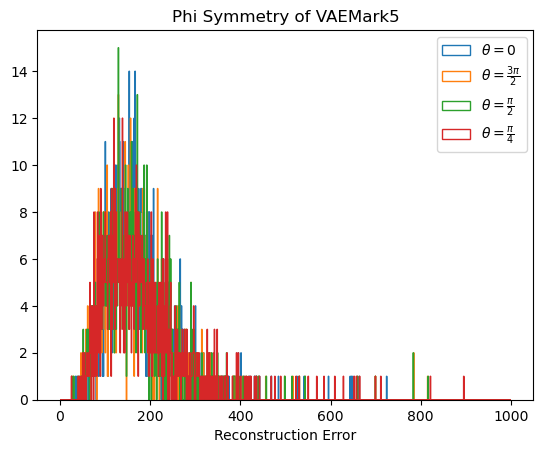

In [30]:
plt.hist(jz0_test_total, bins = 1000, range = (0,1000), histtype= "step", label = r"$\theta = 0$")
plt.hist(jz0_test_3pi4_losses, bins = 1000, range = (0,1000), histtype= "step", label = r"$\theta = \frac{3\pi}{2}$")
plt.hist(jz0_test_pi2_losses, bins = 1000, range = (0,1000), histtype= "step",label = r"$\theta = \frac{\pi}{2}$")
plt.hist(jz0_test_pi4_losses, bins = 1000, range = (0,1000), histtype= "step",label = r"$\theta = \frac{\pi}{4}$")
plt.legend()
plt.xlabel("Reconstruction Error")
plt.title("Phi Symmetry of VAEMark5")
plt.savefig("/home/xzcapask/atlas_ad_hllhc/data/model_data/VAEMark5/phi_invariance_study/phi_symmetry_VAEMark5.png")

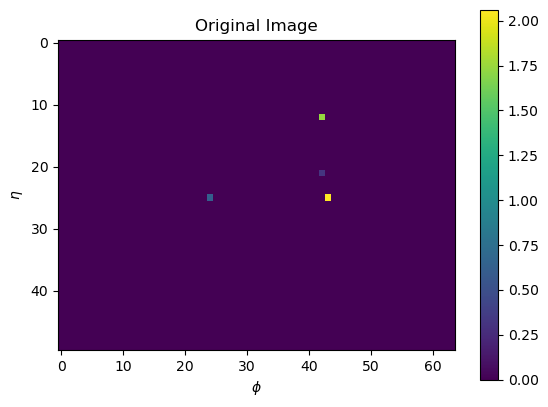

In [9]:
jz0 = ak.from_parquet("/home/xzcapask/ad_trigger_data/JZ0_no_filter.parquet", columns = "cell_towers", row_groups=range(205,206))
jz0 = ak.to_torch(jz0.cell_towers).to(torch.float32)

# Pileup supression
for i in range(len(jz0)):
    image_summed = torch.sum(jz0[i], axis = -1)
    image_eta, image_phi = torch.where(image_summed < 2)
    for j in range(len(image_eta)):      
        jz0[i,image_eta[j], image_phi[j],:] = 0 

plt.imshow(jz0[0,:,:,0])
plt.title("Original Image")
plt.xlabel("$\phi$")
plt.ylabel("$\eta$")
plt.colorbar()
plt.savefig("/home/xzcapask/atlas_ad_hllhc/data/model_data/VAEMark5/image_generation/OriginalVAEMark5Inputtestimage.png")

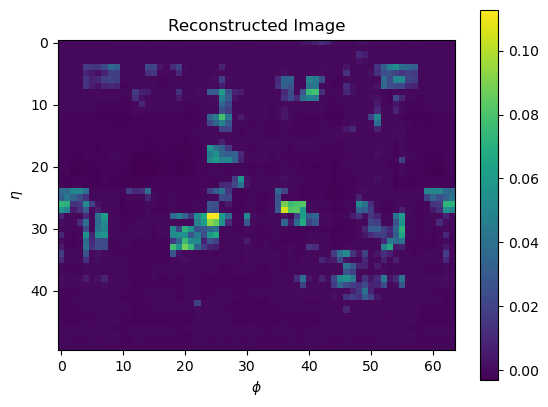

In [10]:
testimage = torch.permute(jz0[0], dims = (2,0,1)).reshape(-1,6,50,64)
testimage.shape
recon_image,mu,logvar = model(testimage)
plt.imshow(recon_image[0,0].detach().numpy())
plt.title("Reconstructed Image")
plt.xlabel("$\phi$")
plt.ylabel("$\eta$")
plt.colorbar()
plt.savefig("/home/xzcapask/atlas_ad_hllhc/data/model_data/VAEMark5/image_generation/ReconstructedVAEMark5Inputtestimage.png")

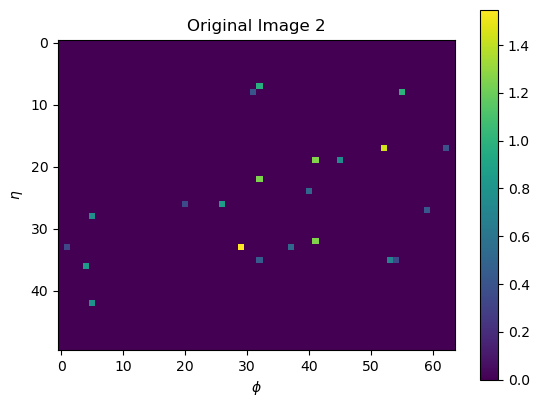

In [11]:
plt.imshow(jz0[1,:,:,0])
plt.title("Original Image 2")
plt.xlabel("$\phi$")
plt.ylabel("$\eta$")
plt.colorbar()
plt.savefig("/home/xzcapask/atlas_ad_hllhc/data/model_data/VAEMark5/image_generation/OriginalVAEMark5Inputtestimage.png")

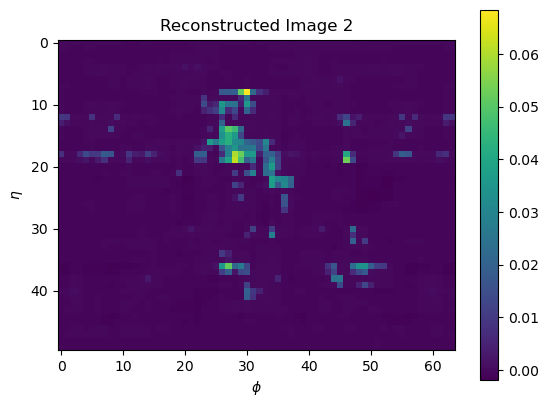

In [12]:
testimage = torch.permute(jz0[1], dims = (2,0,1)).reshape(-1,6,50,64)
testimage.shape
recon_image,mu,logvar = model(testimage)
plt.imshow(recon_image[0,0].detach().numpy())
plt.title("Reconstructed Image 2")
plt.xlabel("$\phi$")
plt.ylabel("$\eta$")
plt.colorbar()
plt.savefig("/home/xzcapask/atlas_ad_hllhc/data/model_data/VAEMark5/image_generation/ReconstructedVAEMark5Inputtestimage.png")

$\beta_t = 0.5 \times (1 + \cos(\pi \times (\frac{current_step \mod T_{cycle}}{T_{cycle}} - 1)))$

$\beta_t = \min(1.0, \frac{current_step}{T_{warmup}})$